# Footprint representativeness after Chu et al. (2021)

A footprint climatology tells you *where the flux came from*. This notebook
answers the complementary question: **how well does that source area stand in
for the target area the site is being used to represent?** — the model grid
cell, the satellite pixel window, or the fixed-radius disc a network product
assigns to the tower.

It walks through the whole method of

> Chu, H., Luo, X., Ouyang, Z., et al. (2021). Representativeness of
> Eddy-Covariance flux footprints for areas surrounding AmeriFlux sites.
> *Agricultural and Forest Meteorology* **301–302**, 108350.
> [doi:10.1016/j.agrformet.2021.108350](https://doi.org/10.1016/j.agrformet.2021.108350)

in four steps:

1. **Build a monthly day/night climatology** from half-hourly tower data.
2. **Load a land-cover raster and an EVI stack** onto the footprint grid.
3. **Run `assess_representativeness`** — the geometry metrics of Eqs. 1–3 and
   the categorical and continuous evaluations of Sect. 2.4.
4. **Produce the four figures** of `representativeness_plotting`.

The theory, all seven equations, and the classification tables are on the
[Footprint representativeness](../representativeness.rst) page. The
[validation](../validation.md) page compares these metrics against the
authors' own published values.

The tower record is the bundled AmeriFlux **US-CRT** BASE file (Curtice
Walter-Berger cropland, north-west Ohio), May–October 2011.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap
from pyproj import Transformer
from rasterio.transform import from_origin

from fluxfootprints import (
    ASYMMETRY_THRESHOLD,
    BIAS_THRESHOLD,
    assess_representativeness,
    build_climatology,
    compute_aerodynamic_params,
    evaluate_landcover,
    load_amf_df,
    load_config,
    monthly_climatologies,
    plot_bias_density,
    plot_footprint_target_scatter,
    plot_landcover_composition,
    plot_level_bars,
    representativeness_table,
    sample_raster_on_grid,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DATA = Path("..") / ".." / "data"        # repository data/ directory
WORK = Path(tempfile.mkdtemp(prefix="representativeness-"))   # scratch GeoTIFFs

SITE = "US-CRT"
TZ = -5                                   # US-CRT records local standard time
START, END = "2011-05-01", "2011-10-31"   # one growing season
STEP, HALF = 10.0, 1000.0                 # 10 m cells on a +/- 1 km domain
RADII = (100.0, 250.0, 500.0, 1000.0)     # target-area radii [m]

print(f"reading tower data from {DATA.resolve().name}/")

reading tower data from data/


> **Note on the target radii.** Chu et al. (2021) evaluate 250 m to 3000 m
> (`fluxfootprints.TARGET_RADII`). US-CRT is a short-canopy cropland site with a
> 2.5 m tower, so its footprint is only a couple of hundred metres across; a
> 1 km domain resolves it well and a 3 km disc would tell us nothing the 1 km
> one does not. The radii above are chosen to bracket *this* footprint. Pass
> `radii=TARGET_RADII` to reproduce the paper's series.

## 1. Build a monthly day/night climatology

Chu et al. aggregate every half-hourly footprint of a calendar month into a
**daytime** and a **nighttime** climatology, truncate each at the contour
enclosing 80 % of the source weight, and rescale the retained cells to sum to
one. That truncated climatology is the unit of analysis for everything
downstream.

First the tower record. `load_config` reads the site's `.ini`, `load_amf_df`
reads the AmeriFlux BASE file, and the columns are renamed to the solver's
names.

In [2]:
config = load_config(DATA / "US-CRT_config.ini")
lat = float(config["station_latitude"])
lon = float(config["station_longitude"])
print(f"{SITE}: {lat:.4f} N, {lon:.4f} E")

frame = load_amf_df(DATA / "AMF_US-CRT_BASE_HH_3-5.csv", config).rename(
    columns={
        "WD": "wind_dir",
        "WS": "umean",
        "USTAR": "ustar",
        "MO_LENGTH": "ol",
        "V_SIGMA": "sigmav",
    }
)

season = frame.loc[START:END, ["wind_dir", "umean", "ustar", "ol", "sigmav"]].dropna()
# Kljun et al. (2015) do not apply in very weak turbulence; the paper filters
# those half-hours out before aggregating (its Table S2).
season = season[season["ustar"] >= 0.15]
season = compute_aerodynamic_params(
    season, inst_height=2.5, crop_height=0.4, veg_type="alfalfa"
)
print(f"{len(season)} half-hours from {season.index.min()} to {season.index.max()}")
season.head()

US-CRT: 41.6285 N, -83.3471 E


5158 half-hours from 2011-05-02 20:00:00 to 2011-10-31 17:30:00


,wind_dir,umean,ustar,ol,sigmav,zm,z0
TIMESTAMP_START,,,,,,,
2011-05-02 20:00:00,267.2680,2.18254,0.16236,27.346434,0.48027,2.232,0.0492
2011-05-03 05:00:00,37.9146,2.49536,0.15085,58.736718,0.66084,2.232,0.0492
2011-05-03 05:30:00,59.4592,4.49470,0.27739,686.206897,0.73097,2.232,0.0492
2011-05-03 06:00:00,64.3045,3.98159,0.26283,401.209677,0.83509,2.232,0.0492
2011-05-03 06:30:00,56.1142,3.40681,0.22406,354.092527,0.86838,2.232,0.0492


`build_climatology` runs the Kljun et al. (2015) parameterisation over every
half-hour and keeps the per-timestep footprints, which is what the monthly
aggregation needs. This takes about a minute at 10 m resolution.

In [3]:
model = build_climatology(
    season,
    model_type="ffp",
    ustar="ustar",
    ol="ol",
    umean="umean",
    sigmav="sigmav",
    wind_dir="wind_dir",
    zm="zm",
    z0="z0",
    h=2000.0,
    dx=STEP,
    dy=STEP,
    domain=(-HALF, HALF, -HALF, HALF),
    verbosity=0,
)

fclim = model.get_footprint_climatology()
captured = float(fclim.sum()) * STEP * STEP
print(fclim.sizes)
print(f"source weight inside the domain: {captured:.1%}")

Frozen({'x': 201, 'y': 201})
source weight inside the domain: 94.3%


The captured fraction matters here more than usual: the truncation fraction is
a fraction of the **full** footprint, not of the captured mass, so a domain
holding much less than 80 % of the weight cannot produce a meaningful 80 %
contour at all. At 94 % we have room to spare. Note that this is set by
*resolution* as much as by extent — the footprint peaks within tens of metres
of a 2.5 m tower, so a coarse grid loses the peak no matter how wide the
domain.

Now the aggregation. Day and night are separated at
$SW_{IN,POT} > 0$; `monthly_climatologies` prefers a precomputed `SW_IN_POT`
column when the record carries one and falls back to solar geometry otherwise,
which is why it wants the tower position and the time zone.

In [4]:
clim = monthly_climatologies(
    model,
    partition="month+daynight",
    latitude=lat,
    longitude=lon,
    tz=TZ,
)
clim

<xarray.Dataset> Size: 4MB
Dimensions:                (month: 6, period: 2, x: 201, y: 201)
Coordinates:
  * month                  (month) datetime64[ns] 48B 2011-05-01 ... 2011-10-01
  * period                 (period) <U9 72B 'daytime' 'nighttime'
  * x                      (x) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03
  * y                      (y) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03
Data variables:
    footprint_climatology  (month, period, x, y) float64 4MB 0.0 0.0 ... 0.0 0.0
    n_times                (month, period) int64 96B 591 214 727 ... 347 509 297
    contour_level          (month, period) float64 96B 4.949e-06 ... 4.877e-06
    contour_n_cells        (month, period) int64 96B 154 130 158 ... 157 214 160
Attributes:
    partition:         month+daynight
    contour_fraction:  0.8
    min_times:         1
    n_timesteps:       5158
    description:       Monthly footprint climatologies truncated at the 80% s...
    reference:         Chu, H., et al. (2021). Agric. For. Meteorol., 301-302...

In [5]:
# Half-hours contributing to each monthly climatology
clim.n_times.to_pandas()

period,daytime,nighttime
month,,
2011-05-01,591,214
2011-06-01,727,162
2011-07-01,713,157
2011-08-01,646,187
2011-09-01,608,347
2011-10-01,509,297


Six months, split day and night: twelve climatologies, each already truncated
at its own 80 % contour and renormalised. `contour_n_cells` shows how compact
they are — 130 to 220 cells of 10 m, so a source area of one to two hectares.

In [6]:
clim.contour_n_cells.to_pandas()

period,daytime,nighttime
month,,
2011-05-01,154,130
2011-06-01,158,128
2011-07-01,172,151
2011-08-01,180,150
2011-09-01,218,157
2011-10-01,214,160


## 2. Load a land-cover raster and an EVI stack

The evaluations of Sect. 2.4 compare the climatology against two external
products: a categorical land-cover map, and a time series of a continuous
vegetation index.

**In production**, `fluxfootprints.representativeness_data` fetches both
straight from Google Earth Engine onto a tower-centred grid — NLCD for the
categorical field, and Landsat 5/8 Collection 2 EVI (the paper's Eq. 4,
cloud-screened to < 1 % obscured) for the continuous one:

```python
from fluxfootprints import fetch_landsat_evi, fetch_nlcd, footprint_grid_geometry

geom = footprint_grid_geometry(model.x, model.y, lat, lon)

nlcd = fetch_nlcd(geom.x_origin, geom.y_origin, geom.crs, year=2016)
scenes = fetch_landsat_evi(
    geom.x_origin, geom.y_origin, geom.crs,
    start="2011-05-01", end="2011-11-01",
)
```

That needs the `gee` extra (`pip install 'fluxfootprints[gee]'`) and an
authenticated Earth Engine project, so this notebook stays offline and
**synthesises two stand-in products instead**: a 30 m land-cover map and six
monthly EVI scenes, written to GeoTIFF exactly as a downloaded product would
be. Everything from here on is the real code path.

The landscape is a plausible one for north-west Ohio: the tower stands in a
soybean field, with a wooded strip to the south-west, pasture to the
north-east, a developed edge to the south-east, and open water to the north.

In [7]:
EPSG = 32617  # WGS 84 / UTM zone 17N, the local zone for US-CRT
east, north = Transformer.from_crs(
    "EPSG:4326", f"EPSG:{EPSG}", always_xy=True
).transform(lon, lat)

RES, N = 30.0, 141                       # 30 m cells, 4.2 km across
half_px = (N // 2) * RES
transform = from_origin(east - half_px - RES / 2, north + half_px + RES / 2, RES, RES)

eastings = (np.arange(N) - N // 2) * RES
northings = (N // 2 - np.arange(N)) * RES
XX, YY = np.meshgrid(eastings, northings)
distance = np.hypot(XX, YY)
bearing = np.degrees(np.arctan2(XX, YY)) % 360.0


def write_geotiff(path, array, dtype, nodata):
    # Write one band to a georeferenced GeoTIFF.
    with rasterio.open(
        path, "w", driver="GTiff", height=N, width=N, count=1,
        dtype=dtype, crs=f"EPSG:{EPSG}", transform=transform, nodata=nodata,
    ) as dst:
        dst.write(array.astype(dtype), 1)


CROPS, FOREST, PASTURE, DEVELOPED, WATER = 82, 41, 81, 21, 11
CLASS_NAMES = {
    82: "Cultivated crops",
    41: "Deciduous forest",
    81: "Hay/pasture",
    21: "Developed, open space",
    11: "Open water",
}

land = np.full((N, N), CROPS, dtype="int16")
land[(distance > 220) & (bearing >= 185) & (bearing < 265)] = FOREST
land[(distance > 320) & (bearing >= 20) & (bearing < 95)] = PASTURE
land[(distance > 700) & (bearing >= 95) & (bearing < 150)] = DEVELOPED
land[(distance > 1300) & ((bearing >= 300) | (bearing < 20))] = WATER

landcover_path = WORK / "US-CRT_landcover_2011.tif"
write_geotiff(landcover_path, land, "int16", 0)

pd.Series(land.ravel()).map(CLASS_NAMES).value_counts(normalize=True).round(3)

Cultivated crops         0.251
Deciduous forest         0.226
Hay/pasture              0.212
Open water               0.157
Developed, open space    0.154
Name: proportion, dtype: float64

The EVI stack gives each class its own seasonal curve. The soybean field swings
from bare soil in May to a closed canopy in August and back; the forest and
pasture are flatter, and the developed and water classes barely move. That
contrast is the whole point: it is what makes a footprint-weighted EVI differ
from a disc-averaged one.

In [8]:
PHENOLOGY = {              # EVI by class and month
    CROPS:     {5: 0.16, 6: 0.34, 7: 0.71, 8: 0.78, 9: 0.44, 10: 0.19},
    FOREST:    {5: 0.42, 6: 0.55, 7: 0.58, 8: 0.57, 9: 0.48, 10: 0.32},
    PASTURE:   {5: 0.38, 6: 0.45, 7: 0.41, 8: 0.39, 9: 0.40, 10: 0.33},
    DEVELOPED: {5: 0.15, 6: 0.19, 7: 0.20, 8: 0.20, 9: 0.18, 10: 0.14},
    WATER:     {5: 0.03, 6: 0.03, 7: 0.04, 8: 0.04, 9: 0.03, 10: 0.02},
}

rng = np.random.default_rng(11)
evi_paths = {}
for month in range(5, 11):
    stamp = pd.Timestamp(f"2011-{month:02d}-15")   # one clear scene per month
    field = np.zeros((N, N))
    for code_, curve in PHENOLOGY.items():
        field = np.where(land == code_, curve[month], field)
    field = field + 0.03 * rng.standard_normal((N, N))   # within-class texture
    path = WORK / f"US-CRT_evi_{stamp:%Y%m%d}.tif"
    write_geotiff(path, field, "float32", np.nan)
    evi_paths[stamp] = path

list(evi_paths)

[Timestamp('2011-05-15 00:00:00'),
 Timestamp('2011-06-15 00:00:00'),
 Timestamp('2011-07-15 00:00:00'),
 Timestamp('2011-08-15 00:00:00'),
 Timestamp('2011-09-15 00:00:00'),
 Timestamp('2011-10-15 00:00:00')]

`sample_raster_on_grid` georeferences the tower-centred footprint grid and warps
each raster onto it, so the products line up with the climatology cell for cell.
Land-cover codes must go through **nearest neighbour** — bilinear resampling of
class codes invents classes that are not in the legend — which is what
`categorical=True` selects.

In [9]:
landcover = sample_raster_on_grid(
    landcover_path, model.x, model.y, lat, lon, categorical=True
)
scenes = {
    stamp: sample_raster_on_grid(path, model.x, model.y, lat, lon)
    for stamp, path in evi_paths.items()
}

print(landcover.dims, landcover.shape)
print("classes on the grid:", sorted(np.unique(landcover.values[np.isfinite(landcover.values)])))

('x', 'y') (201, 201)
classes on the grid: [np.float64(11.0), np.float64(21.0), np.float64(41.0), np.float64(81.0), np.float64(82.0)]


Before running the analysis, it is worth seeing what the tower actually sees
against what the target discs contain.

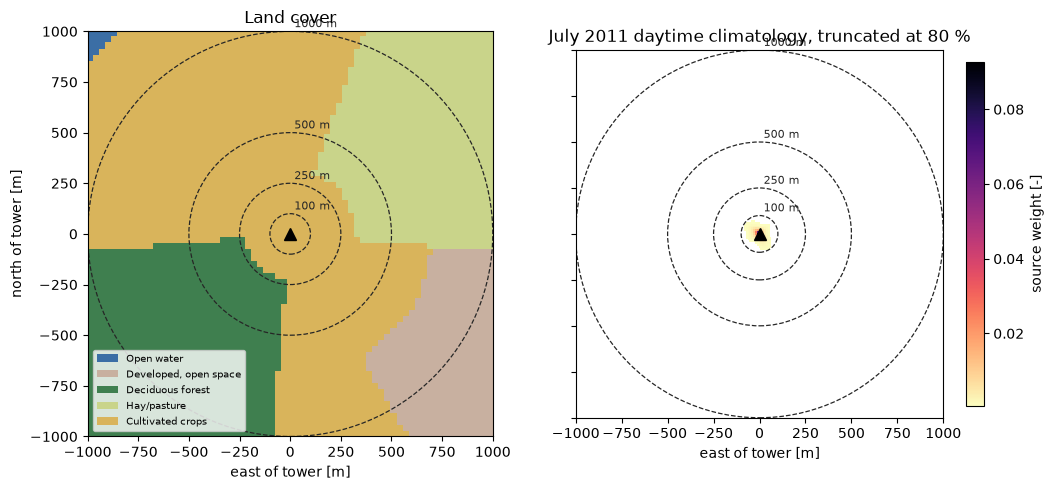

In [10]:
july_day = clim.footprint_climatology.sel(period="daytime", month="2011-07-01")

codes = sorted(CLASS_NAMES)
cmap = ListedColormap(["#3b6ea5", "#c8b0a0", "#3f7f4f", "#c9d48a", "#d9b45b"])
norm = BoundaryNorm([c - 0.5 for c in codes] + [codes[-1] + 0.5], cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

axes[0].pcolormesh(model.x, model.y, landcover.T, cmap=cmap, norm=norm, shading="auto")
axes[0].set_title("Land cover")

weights = july_day.where(july_day > 0)
mesh = axes[1].pcolormesh(model.x, model.y, weights.T, cmap="magma_r", shading="auto")
fig.colorbar(mesh, ax=axes[1], label="source weight [-]", shrink=0.85)
axes[1].set_title("July 2011 daytime climatology, truncated at 80 %")

for ax in axes:
    for radius in RADII:
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, ec="0.15", lw=0.9, ls="--"))
        ax.annotate(f"{radius:.0f} m", (0, radius), textcoords="offset points",
                    xytext=(3, 3), fontsize=8, color="0.15")
    ax.plot(0, 0, marker="^", ms=9, color="k")
    ax.set_aspect("equal")
    ax.set_xlim(-HALF, HALF)
    ax.set_ylim(-HALF, HALF)
    ax.set_xlabel("east of tower [m]")
axes[0].set_ylabel("north of tower [m]")

handles = [plt.Rectangle((0, 0), 1, 1, fc=cmap(norm(c))) for c in codes]
axes[0].legend(handles, [CLASS_NAMES[c] for c in codes], loc="lower left", fontsize=7.5)
fig.tight_layout()

That is the whole problem in one picture. The source area is a compact lobe a
couple of hundred metres across, entirely inside the soybean field; the 500 m
and 1000 m discs take in forest, pasture, developed ground, and water that the
tower never sees.

## 3. Run `assess_representativeness`

One call drives everything: the geometry metrics of Eqs. 1–3, the categorical
comparison and the continuous one at every radius, and the three-level
classification of each. Passing the already-aggregated `clim` Dataset rather
than the model reuses the aggregation instead of repeating it.

In [11]:
results = assess_representativeness(
    clim,
    station_lat=lat,
    station_lon=lon,
    site_id=SITE,
    landcover=landcover,
    continuous=scenes,
    radii=RADII,
    tz=TZ,
)
print(results.shape)
results.reset_index()[["scope", "kind"]].value_counts()

(126, 34)


scope      kind       
period     categorical    48
           continuous     48
           climatology    12
site       categorical     8
           continuous      8
site_year  climatology     2
Name: count, dtype: int64

The frame is tidy and sparse: rows of three scopes and three kinds, indexed by
`(site, year, month, period, radius, variable)`, with each row carrying only
the columns its own analysis produces. Select a slice before reading values off
it.

### Climatology metrics — Eqs. 1–3

In [12]:
results.query("scope == 'site_year' and kind == 'climatology'").reset_index()[
    ["period", "fetch", "area", "symmetry", "seasonal_overlap", "daynight_overlap"]
].round(3)

,period,fetch,area,symmetry,seasonal_overlap,daynight_overlap
0,daytime,98.873,18266.667,0.597,0.918,0.959
1,nighttime,102.545,14600.000,0.469,0.842,0.959


Reading these:

- **X80 ≈ 100 m, A80 ≈ 1.5–1.8 ha.** A short canopy on a low tower gives a
  small source area. The nighttime footprint *reaches* farther than the
  daytime one — as the paper finds for > 95 % of its site-years — but here it
  encloses less area, so nights are the more elongated of the two.
- **S80 ≈ 0.60 day, 0.47 night**, both comfortably above
  `ASYMMETRY_THRESHOLD` (0.30). The wind rose is broad enough that the source
  area stays roughly disc-like rather than collapsing into a single lobe,
  though the lower nighttime value reflects exactly the elongation above.
- **O80,season ≈ 0.92 day / 0.84 night** (Eq. 2). The daytime source area is
  stable through the season; at night it wanders more, which is the usual
  signature of light, variable winds under a stable boundary layer.
- **O80,daynight ≈ 0.96** (Eq. 3). Day and night sample nearly the same ground
  here — this site has no drainage flow to send nights somewhere else.

### Land-cover representativeness — Sect. 2.4

In [13]:
categorical = results.query("scope == 'site' and kind == 'categorical'").reset_index()
categorical[
    ["period", "radius", "dominant_class", "value_footprint", "value_target",
     "chi2", "p_value", "level"]
].round(3)

,period,radius,dominant_class,value_footprint,value_target,chi2,p_value,level
0,daytime,100.0,82,1.0,1.000,0.000,1.0,high
1,daytime,250.0,82,1.0,0.957,88.851,0.0,low
2,daytime,500.0,82,1.0,0.699,3375.424,0.0,low
3,daytime,1000.0,82,1.0,0.524,28581.048,0.0,low
4,nighttime,100.0,82,1.0,1.000,0.000,1.0,high
5,nighttime,250.0,82,1.0,0.957,88.851,0.0,low
6,nighttime,500.0,82,1.0,0.699,3375.424,0.0,low
7,nighttime,1000.0,82,1.0,0.524,28581.048,0.0,low


The dominant class is cultivated crops (NLCD 82) everywhere, and it holds
**100 %** of the footprint weight at every radius — the footprint never leaves
the field. What changes is the disc: 100 % crop at 100 m, 96 % at 250 m, 70 %
at 500 m, and 52 % at 1000 m.

The `level` column falls to `low` from 250 m outwards, and it is worth being
precise about *why*. Both shares are still above 80 % at 250 m, so the
percentage criteria are met; it is the chi-square test that fails. That test
scales both compositions to pseudo-counts by the number of classified cells in
the target area — and on a 10 m grid a 250 m disc holds nearly 2000 of them, so
even a 4 % difference in composition is resolved as significant. **Read the
p-value as a comparison against the paper's fixed 30 m Landsat grid, not as an
absolute significance**; a finer grid makes the same test stricter. The
`_composition_chi_square` docstring spells this out.

### Continuous-field representativeness — Eqs. 5–7

In [14]:
periods = results.query("scope == 'period' and kind == 'continuous'").reset_index()
periods.groupby("radius").agg(
    mean_footprint_evi=("value_footprint", "mean"),
    mean_target_evi=("value_target", "mean"),
    mean_bias=("bias", "mean"),
    within_10pct=("within_threshold", "mean"),
).round(3)

,mean_footprint_evi,mean_target_evi,mean_bias,within_10pct
radius,,,,
100.0,0.439,0.437,0.010,1.0
250.0,0.439,0.438,-0.003,1.0
500.0,0.439,0.440,-0.057,0.5
1000.0,0.439,0.419,-0.023,0.333


`within_10pct` is the share of matched scenes whose sensor location bias
(Eq. 6) sits inside `BIAS_THRESHOLD` (±10 %). It falls from **1.00** at 100 m
and 250 m to **0.50** at 500 m and **0.33** at 1000 m: the wider the disc, the
less often the tower's own view of it is within 10 % of the truth. This is the
paper's Sect. 3.3 result, and it comes straight off these rows.

In [15]:
continuous = results.query("scope == 'site' and kind == 'continuous'").reset_index()
continuous[
    ["period", "radius", "slope", "intercept", "r_squared", "p_value", "n",
     "sufficient", "level"]
].round(3)

,period,radius,slope,intercept,r_squared,p_value,n,sufficient,level
0,daytime,100.0,1.014,-0.007,1.000,0.0,6,True,high
1,daytime,250.0,0.989,0.005,0.999,0.0,6,True,high
2,daytime,500.0,0.785,0.096,0.995,0.0,6,True,medium
3,daytime,1000.0,0.628,0.144,0.986,0.0,6,True,medium
4,nighttime,100.0,1.017,-0.009,1.000,0.0,6,True,high
5,nighttime,250.0,0.991,0.003,0.999,0.0,6,True,high
6,nighttime,500.0,0.787,0.095,0.995,0.0,6,True,medium
7,nighttime,1000.0,0.629,0.143,0.986,0.0,6,True,medium


The Eq. 7 model II slope $\beta_1$ falls from **1.01** at 100 m to **0.63** at
1000 m. A slope below one means the footprint-weighted EVI swings further than
the disc average does — the tower tracks its own field's phenology, while the
disc dilutes that swing with forest, pasture, and water that barely change
through the season. The classification drops from `high` to `medium` as the
disc widens, even though $R^2$ stays above 0.98 throughout: it is the *slope*
leaving the 0.9–1.1 band that costs the site its `high`.

## 4. The four figures

`fluxfootprints.representativeness_plotting` draws the paper's four diagnostics.
Each takes what the analysis functions already return and hands back
`(fig, ax)` without showing or saving anything, so titles, layout, and output
stay with the caller.

### Fig. 1e — land-cover composition

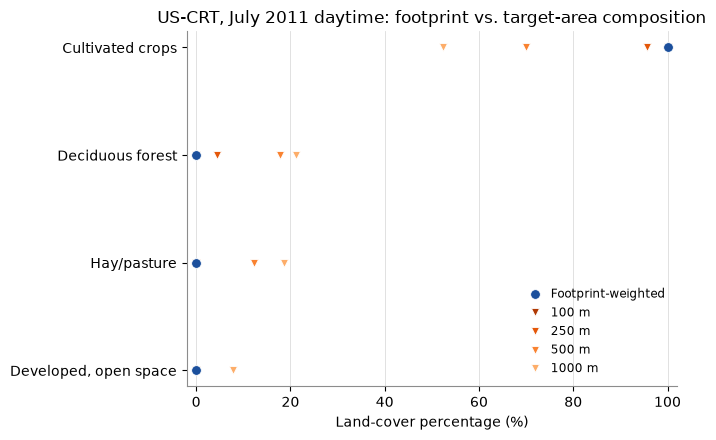

In [16]:
july_categorical = evaluate_landcover(july_day, landcover, radii=RADII)

fig, ax = plot_landcover_composition(july_categorical, class_labels=CLASS_NAMES)
ax.set_title("US-CRT, July 2011 daytime: footprint vs. target-area composition")
fig.tight_layout()

The filled circle is the footprint-weighted share, the triangles the target-area
shares on a dark-to-light radius ramp. Crops sit at 100 % under the footprint
and trail leftwards as the disc widens; every other class trails the other way,
from 0 % under the footprint out to its share of the 1 km disc.

### Figs. 1f and 6 — footprint against target-area values

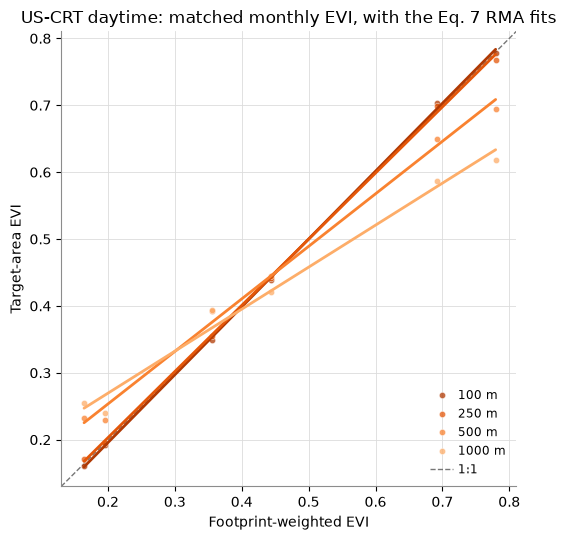

In [17]:
daytime_pairs = periods.query("period == 'daytime'")

fig, ax = plot_footprint_target_scatter(daytime_pairs, variable="EVI")
ax.set_title("US-CRT daytime: matched monthly EVI, with the Eq. 7 RMA fits")
fig.tight_layout()

Six matched scenes per radius, under the reduced major axis fit of Eq. 7 and the
1:1 line. The 100 m series lies on 1:1; the wider discs pivot away from it,
flattening exactly as their slopes in the table above say they should. The line
is the RMA rather than ordinary least squares because both axes are spatial
averages of one noisy raster and both carry error — an OLS slope would sit
systematically shallower than the values the paper's Table 1 reports.

### Fig. 7 — density of the sensor location bias

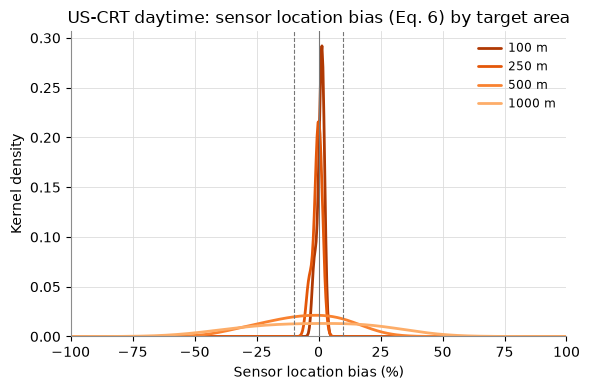

In [18]:
fig, ax = plot_bias_density(daytime_pairs, threshold=BIAS_THRESHOLD)
ax.set_title("US-CRT daytime: sensor location bias (Eq. 6) by target area")
fig.tight_layout()

One Gaussian kernel density per radius over the per-scene biases. The peak is
tall and narrow at 100 m and collapses into a broad, flat spread by 1000 m —
the paper's Fig. 7 result, that the wider the disc, the further a given month's
footprint-weighted value strays from it. The dashed guides are the ±10 % of
`BIAS_THRESHOLD`; the published figure draws no guides, so they are opt-in.

### Figs. 5 and 8 — the three-level index across target areas

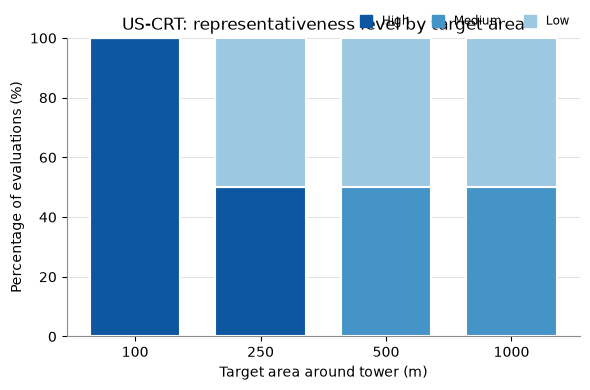

In [19]:
site_levels = results.query("scope == 'site'").reset_index()

fig, ax = plot_level_bars(site_levels, level_column="level")
ax.set_ylabel("Percentage of evaluations (%)")
ax.set_title("US-CRT: representativeness level by target area")
fig.tight_layout()

In the paper this panel pools hundreds of sites, and each bar is the share of
*sites* still classified `high` at that radius. Here there is one site, so the
bar pools its eight site-level verdicts instead — land cover and vegetation
index, daytime and nighttime. The shape is the paper's all the same: wholly
`high` at 100 m, and progressively less so as the disc widens.

## 5. Exporting in the published layouts

`representativeness_table` reshapes the tidy frame into the column schema of
the authors' Datasets S4–S6, so a local analysis can be read next to, or
concatenated with, the published tables.
`export_representativeness_tables` writes all three to CSV in one call.

In [20]:
representativeness_table(results, "S6").round(3)

,SITE_ID,PERIOD,TARGET_AREA,VARIABLE,N,INTERCEPT,INTERCEPT_LCL,INTERCEPT_UCL,SLOPE,SLOPE_LCL,SLOPE_UCL,R2,RMSE,MAE,REP_EVI
0,US-CRT,daytime,100.0,EVI,6,-0.007,-0.021,0.006,1.014,0.984,1.046,1.000,0.006,0.005,high
1,US-CRT,daytime,250.0,EVI,6,0.005,-0.010,0.020,0.989,0.955,1.024,0.999,0.006,0.005,high
2,US-CRT,daytime,500.0,EVI,6,0.096,0.060,0.129,0.785,0.710,0.868,0.995,0.052,0.045,medium
3,US-CRT,daytime,1000.0,EVI,6,0.144,0.095,0.185,0.628,0.534,0.739,0.986,0.091,0.077,medium
4,US-CRT,nighttime,100.0,EVI,6,-0.009,-0.023,0.004,1.017,0.987,1.047,1.000,0.007,0.006,high
5,US-CRT,nighttime,250.0,EVI,6,0.003,-0.012,0.018,0.991,0.957,1.026,0.999,0.006,0.004,high
6,US-CRT,nighttime,500.0,EVI,6,0.095,0.058,0.128,0.787,0.712,0.870,0.995,0.051,0.044,medium
7,US-CRT,nighttime,1000.0,EVI,6,0.143,0.094,0.184,0.629,0.535,0.741,0.986,0.091,0.077,medium


## What to take away

- The footprint is **not** the target area, and the gap is a function of
  radius. At US-CRT the tower represents its own 100 m surroundings almost
  perfectly and a 1 km cell only loosely — worth knowing before the site is
  used to validate a kilometre-scale product.
- **Both evaluations agree on the direction** and disagree on the pace. The
  categorical index falls off a cliff at 250 m because the chi-square test is
  sharpened by the fine grid; the continuous index degrades gradually. Read
  them together, and read the p-value with the grid in mind.
- The **slope of Eq. 7** is the most informative single number here. A slope
  below one says the tower's field swings more than the surrounding cell does,
  which is what upscaling from this site would have to correct for.
- The land-cover and EVI products here are **synthetic**. Swap in
  `fetch_nlcd` and `fetch_landsat_evi`, or any pair of rasters on disc, and
  nothing else in the notebook changes.

### Next

- [Footprint representativeness](../representativeness.rst) — the theory, all
  seven equations, and the classification tables.
- [Validation against Chu et al. (2021)](../validation.md) — these metrics
  recomputed from the authors' own published climatology rasters.